### Classification
Array -> Vector -> Time Series -> Matrices -> Multi-variate time series -> Model -> Regression -> Classification

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
# Download OHLC data for BTC-USD
url = 'https://drive.google.com/uc?export=download&id=1qnX9GpiL5Ii1FEnHTIAzWnxNejWnilKp'
btcusd = pd.read_csv(url, parse_dates=["open_time"], index_col='open_time')

In [5]:
btcusd['close_log_return'] = np.log(btcusd['close'] / btcusd['close'].shift()) 
btcusd['close_log_return_lag_1'] = btcusd['close_log_return'].shift()
btcusd['close_log_return_lag_2'] = btcusd['close_log_return'].shift(2)
btcusd['close_log_return_lag_3'] = btcusd['close_log_return'].shift(3)
btcusd = btcusd.dropna()
btcusd

,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
open_time,,,,,,,,,
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299,-0.000263,-0.001072,-0.012063,-0.005189
2020-11-27 05:00:00,17079.55,17350.00,17078.78,17267.54,13783.564,0.010946,-0.000263,-0.001072,-0.012063
2020-11-27 06:00:00,17267.54,17316.32,17177.00,17286.70,9598.037,0.001109,0.010946,-0.000263,-0.001072
2020-11-27 07:00:00,17286.70,17297.90,17040.00,17105.25,13115.712,-0.010552,0.001109,0.010946,-0.000263
2020-11-27 08:00:00,17106.79,17116.04,16714.92,16857.75,31574.365,-0.014575,-0.010552,0.001109,0.010946
...,...,...,...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178,0.003138,-0.004455,0.006797,0.001525
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547,0.001790,0.003138,-0.004455,0.006797
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325,-0.003528,0.001790,0.003138,-0.004455


### Create Binary Classification Target
- 1 -> Long -> Price moves up
- 2 -> Short -> Price moves down (we do not use -1 for short as it's a probability space [0, 1])

In [6]:
btcusd['close_log_return_dir'] = btcusd['close_log_return'].map(lambda x: 1 if x > 0 else 0)
btcusd

,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_dir
open_time,,,,,,,,,,
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299,-0.000263,-0.001072,-0.012063,-0.005189,0
2020-11-27 05:00:00,17079.55,17350.00,17078.78,17267.54,13783.564,0.010946,-0.000263,-0.001072,-0.012063,1
2020-11-27 06:00:00,17267.54,17316.32,17177.00,17286.70,9598.037,0.001109,0.010946,-0.000263,-0.001072,1
2020-11-27 07:00:00,17286.70,17297.90,17040.00,17105.25,13115.712,-0.010552,0.001109,0.010946,-0.000263,0
2020-11-27 08:00:00,17106.79,17116.04,16714.92,16857.75,31574.365,-0.014575,-0.010552,0.001109,0.010946,0
...,...,...,...,...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178,0.003138,-0.004455,0.006797,0.001525,1
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547,0.001790,0.003138,-0.004455,0.006797,1
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325,-0.003528,0.001790,0.003138,-0.004455,0


In [7]:
btcusd['close_log_return_dir'].value_counts()

close_log_return_dir
1    22021
0    21415
Name: count, dtype: int64

In [8]:
def time_split(x, train_size = 0.5):
    i = int(len(x) * train_size)
    return x[:i].copy(), x[i:].copy()

btcusd_train, btcusd_test = time_split(btcusd, train_size = 0.7)

### Check Classification Balance of Train/Test Split

In [9]:
btcusd_test['close_log_return_dir'].value_counts()

close_log_return_dir
1    6575
0    6456
Name: count, dtype: int64

In [10]:
btcusd_train['close_log_return_dir'].value_counts()

close_log_return_dir
1    15446
0    14959
Name: count, dtype: int64

### Create Model (Logistic Regression)

In [15]:
from io import SEEK_END
import random
import os

SEED = 99

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEEK_END)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED) # For single-GPU setups
    torch.cuda.manual_seed_all(SEED) # For multi-GPU setups

features = ['close_log_return_lag_3']
target = 'close_log_return_dir'

X_train = torch.tensor(btcusd_train[features].values, dtype=torch.float32)
X_test = torch.tensor(btcusd_test[features].values, dtype=torch.float32)

y_train = torch.tensor(btcusd_train[target].values, dtype=torch.float32).unsqueeze(1) # Add an extra dimension for the target variable
y_test = torch.tensor(btcusd_test[target].values, dtype=torch.float32).unsqueeze(1) # Add an extra dimension for the target variable

no_features = len(features)

# Define the Logistic Regression Model (It's a siple Linear layer that outputs logits (W * x + b))
class LogisticRegression(nn.Module):
    def __init__(self, input_size):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.linear(x)
    
model = LogisticRegression(no_features)
criterion = nn.BCEWithLogitsLoss() # Binary Cross-Entropy with Logits
optimizer = optim.SGD(model.parameters(), lr = 0.01)

for epoch in range(9000):

    # Clear gradients
    optimizer.zero_grad()
    
    # Forward pass
    y_pred_logits = model(X_train)

    # Compute loss
    loss = criterion(y_pred_logits, y_train)

    # Compute gradients
    loss.backward()

    # Update Model parameters
    optimizer.step()

    if epoch % 1000 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())


print("\nFinal weight", model.linear.weight.data)
print("Final Bias", model.linear.bias.data)


with torch.no_grad():
    y_pred_logits = model(X_test)
    y_pred_prob = torch.sigmoid(y_pred_logits) # Convert logits to probabilities
    y_pred_binary = (y_pred_prob >= 0.5).float() # Classify based on a threshold of 0.5

y_test_np = y_test.squeeze().numpy() # Convert to 1D array
y_pred_binary_np = y_pred_binary.squeeze().numpy() # Convert to 1D array
y_pred_prob_np = y_pred_prob.squeeze().numpy() # Convert to 1D array

accuracy = np.mean(y_pred_binary_np == y_test_np)

buy_signals = np.sum(y_pred_binary_np == 1)
sell_signals = np.sum(y_pred_binary_np == 0)

print("\n--- Model Evaluation ---")
print("Test Accuracy:", accuracy)
print("Buy Signals:", buy_signals)
print("Sell Signals:", sell_signals)
print("Predicted Probabilities (first 10):", y_pred_prob_np[:10])


Epoch: 0 Loss: 0.7922163605690002
Epoch: 1000 Loss: 0.6936994194984436
Epoch: 2000 Loss: 0.6929551362991333
Epoch: 3000 Loss: 0.6929500699043274
Epoch: 4000 Loss: 0.6929499506950378
Epoch: 5000 Loss: 0.6929499506950378
Epoch: 6000 Loss: 0.6929497718811035
Epoch: 7000 Loss: 0.6929497718811035
Epoch: 8000 Loss: 0.692949652671814

Final weight tensor([[-0.8009]])
Final Bias tensor([0.0321])

--- Model Evaluation ---
Test Accuracy: 0.504566034839997
Buy Signals: 13027
Sell Signals: 4
Predicted Probabilities (first 10): [0.50813955 0.5085432  0.5072201  0.5085287  0.5078934  0.50742507
 0.508392   0.50724727 0.5072779  0.506708  ]


### Evaluate Model's Predictability (Out-of-sample)

In [16]:
# Add model out-of-sample predictions
btcusd_test['y_pred_binary'] = y_pred_binary_np
btcusd_test['y_pred_prob'] = y_pred_prob_np
btcusd_test[['close_log_return', 'y_pred_binary', 'y_pred_prob']]

,close_log_return,y_pred_binary,y_pred_prob
open_time,,,
2024-05-17 01:00:00,-0.002554,1.0,0.508140
2024-05-17 02:00:00,0.000620,1.0,0.508543
2024-05-17 03:00:00,0.002960,1.0,0.507220
2024-05-17 04:00:00,-0.001871,1.0,0.508529
2024-05-17 05:00:00,0.003848,1.0,0.507893
...,...,...,...
2025-11-10 19:00:00,0.003138,1.0,0.507712
2025-11-10 20:00:00,0.001790,1.0,0.506657
2025-11-10 21:00:00,-0.003528,1.0,0.508909


### Encode Directional Signal
- 1 -> Go long -> Bet price goes up
- 2 -> Go short -> Bet price goes down

In [17]:
btcusd_test['dir_signal'] = np.where(btcusd_test['y_pred_binary'] == 1, 1, -1)
btcusd_test[['close_log_return', 'y_pred_binary', 'y_pred_prob', 'dir_signal']]

,close_log_return,y_pred_binary,y_pred_prob,dir_signal
open_time,,,,
2024-05-17 01:00:00,-0.002554,1.0,0.508140,1
2024-05-17 02:00:00,0.000620,1.0,0.508543,1
2024-05-17 03:00:00,0.002960,1.0,0.507220,1
2024-05-17 04:00:00,-0.001871,1.0,0.508529,1
2024-05-17 05:00:00,0.003848,1.0,0.507893,1
...,...,...,...,...
2025-11-10 19:00:00,0.003138,1.0,0.507712,1
2025-11-10 20:00:00,0.001790,1.0,0.506657,1
2025-11-10 21:00:00,-0.003528,1.0,0.508909,1


### Evaluate Prediction Balance (Direction Distribution)

In [18]:
btcusd_test['dir_signal'].value_counts()

dir_signal
 1    13027
-1        4
Name: count, dtype: int64

### Evaluate Model's Probability

<Axes: xlabel='open_time'>

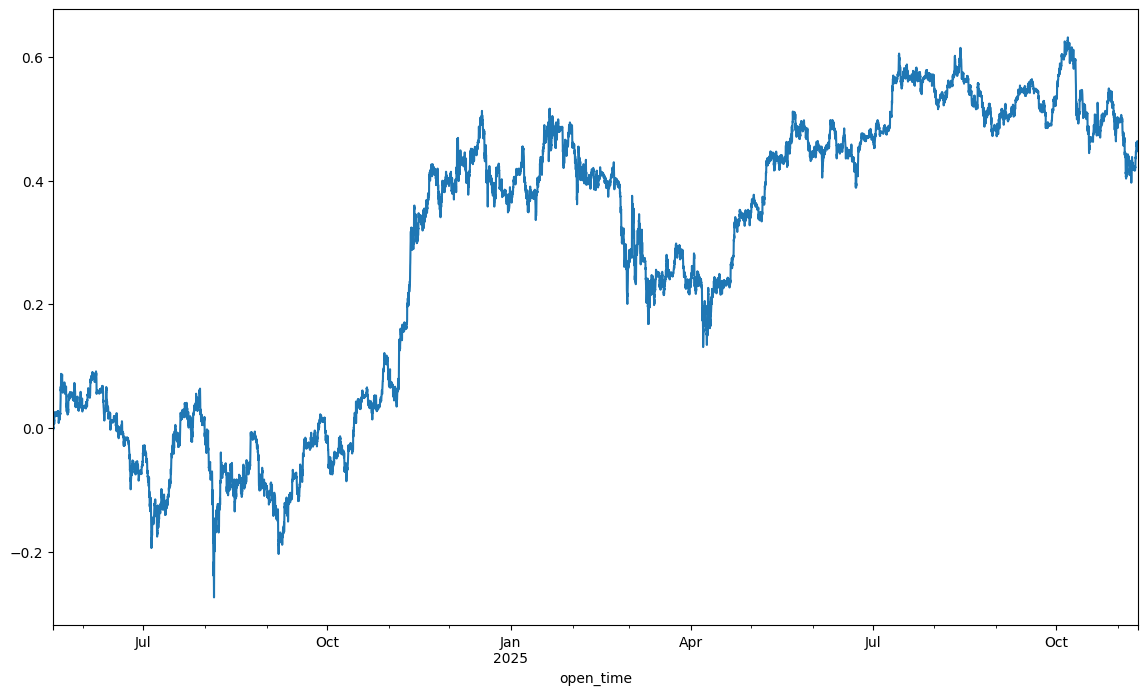

In [23]:
btcusd_test['trade_log_return'] = btcusd_test['dir_signal'] * btcusd_test['close_log_return']
btcusd_test['trade_log_return'].cumsum().plot(figsize=(14, 8))

<Axes: xlabel='open_time'>

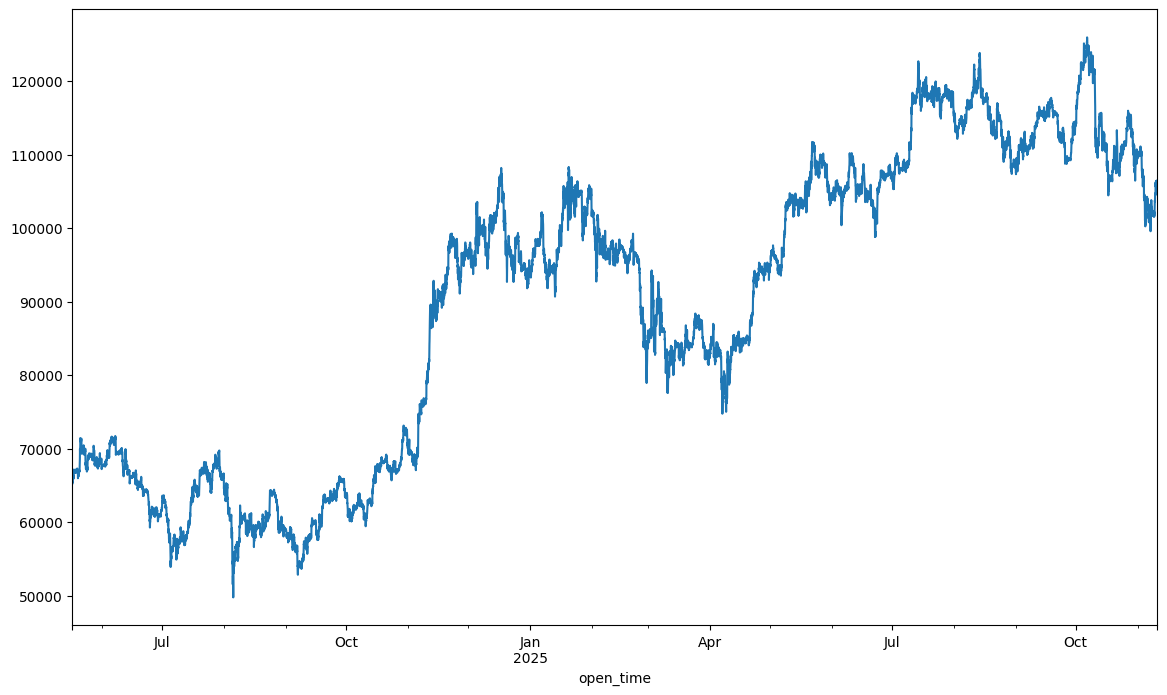

In [ ]:
# Because the model's just predicting to go up all the time there's no real predictive power
# As a result, the equity curve looks just like the close one
# Just by luck this would work as there's a positive trend
btcusd_test['close'].plot(figsize=(14, 8))

### No Discriminative Power == No Predictive Power

### Research New Model